# Loss Evaluation for version_110

This notebook loads Lightning metrics and visualizes training/validation loss trends.

- Source: `lightning_logs/version_110/metrics.csv`
- Main targets: `train_loss`, `val_loss`
- Includes smoothing and best-checkpoint summary

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

metrics_path = Path("/cluster/project/math/andtran/develop/masters_thesis/code/lightning_logs/version_110/metrics.csv")
print(f"Reading: {metrics_path}")

Reading: /cluster/project/math/andtran/develop/masters_thesis/code/lightning_logs/version_110/metrics.csv


In [11]:
# Load metrics with a tolerant parser in case of occasional malformed lines
metrics = pd.read_csv(metrics_path, engine="python", on_bad_lines="skip")

# Keep only relevant columns if present
preferred_cols = ["epoch", "step", "train_loss", "val_loss", "train/loss_total", "val/loss_total"]
available_cols = [c for c in preferred_cols if c in metrics.columns]

if not available_cols:
    raise ValueError("Could not find expected loss columns in metrics.csv")

df = metrics[available_cols].copy()

# Convert to numeric where possible
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort in training order
sort_cols = [c for c in ["epoch", "step"] if c in df.columns]
if sort_cols:
    df = df.sort_values(sort_cols).reset_index(drop=True)

print("Columns used:", list(df.columns))
print("Rows:", len(df))
df.tail()

Columns used: ['epoch', 'step', 'train_loss', 'val_loss', 'train/loss_total', 'val/loss_total']
Rows: 1000


,epoch,step,train_loss,val_loss,train/loss_total,val/loss_total
995,497,42827,0.003674,NaN,0.003674,NaN
996,498,42913,NaN,0.003603,NaN,0.003603
997,498,42913,0.003677,NaN,0.003677,NaN
998,499,42999,NaN,0.003951,NaN,0.003951
999,499,42999,0.003618,NaN,0.003618,NaN


Train column: train_loss
Val column:   val_loss

Best validation epoch:
epoch    464.000000
train      0.003794
val        0.002852
Name: 464, dtype: float64


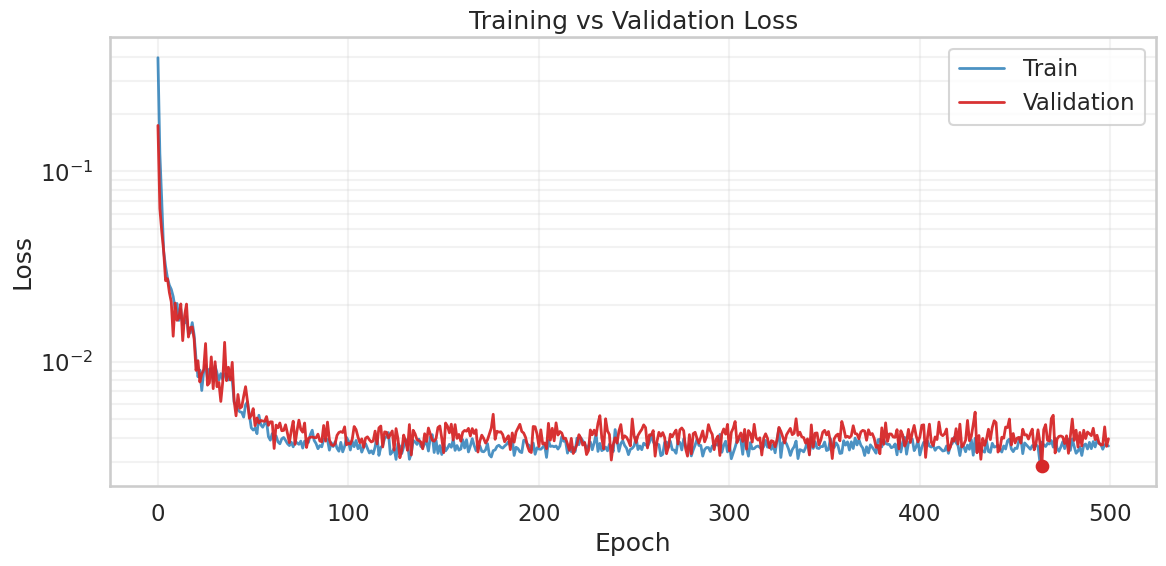

In [12]:
# Pick training/validation columns with fallbacks
train_col = "train_loss" if "train_loss" in df.columns else "train/loss_total"
val_col = "val_loss" if "val_loss" in df.columns else "val/loss_total"

if train_col not in df.columns or val_col not in df.columns:
    raise ValueError(f"Missing required loss columns. train={train_col in df.columns}, val={val_col in df.columns}")

plot_df = df[[c for c in ["epoch", train_col, val_col] if c in df.columns]].copy()
plot_df = plot_df.rename(columns={train_col: "train", val_col: "val"})

if "epoch" not in plot_df.columns:
    raise ValueError("Epoch column not found in metrics data.")

plot_df = plot_df.dropna(subset=["epoch"]).copy()
plot_df["epoch"] = plot_df["epoch"].astype(int)

# Aggregate at epoch level for cleaner comparison
plot_epoch = (
    plot_df.groupby("epoch", as_index=False)
    .agg(train=("train", "mean"), val=("val", "mean"))
    .sort_values("epoch")
    .reset_index(drop=True)
)

# Log-scale requires strictly positive values
eps = 1e-8
for col in ["train", "val"]:
    plot_epoch[col] = plot_epoch[col].clip(lower=eps)

# Best validation epoch
best_val_idx = plot_epoch["val"].idxmin()
best_row = plot_epoch.loc[best_val_idx]

print(f"Train column: {train_col}")
print(f"Val column:   {val_col}")
print("\nBest validation epoch:")
print(best_row[["epoch", "train", "val"]])

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.lineplot(data=plot_epoch, x="epoch", y="train", ax=ax, label="Train", color="#1f77b4", alpha=0.8, linewidth=2.0)
sns.lineplot(data=plot_epoch, x="epoch", y="val", ax=ax, label="Validation", color="#d62728", alpha=0.95, linewidth=2.0)
ax.scatter([best_row["epoch"]], [best_row["val"]], color="#d62728", s=70, zorder=5)

ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.grid(True, alpha=0.25, which="both")
ax.legend()

plt.tight_layout()
plt.show()